In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import functions as f

In [2]:
#loading dataset df_final_demo
df_final_demo = f.load_data("./data/Raw_data/df_final_demo.txt")
df_final_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [3]:
df_final_demo['gendr'] = df_final_demo['gendr'].replace('X', 'U')

In [4]:
#loading dataset df_final_experiment_clients
df_final_experiment_clients = f.load_data("./data/Raw_data/df_final_experiment_clients.txt")
df_final_experiment_clients.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [5]:
#loading dataset df_final_web_data_pt_1
df_final_web_data_pt_1 = f.load_data("./data/Raw_data/df_final_web_data_pt_1.txt")
df_final_web_data_pt_1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [6]:
#loading dataset df_final_web_data_pt_2
df_final_web_data_pt_2 = f.load_data("./data/Raw_data/df_final_web_data_pt_2.txt")
df_final_web_data_pt_2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [7]:
#loading dataset merging the two dataset
df_final_web_data = pd.concat([df_final_web_data_pt_1, df_final_web_data_pt_2], ignore_index = True)
df_final_web_data.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [8]:
df_final_demo.dropna(inplace=True)

In [9]:
df_experiment = df_final_experiment_clients.dropna(subset=['Variation'])

# These 3 datasets to be used after final cleaning for further analysis
df_final_demo,
df_experiment,
df_final_web_data

## Completion Rate: The proportion of users who reach the final 'confirm' step.

In [10]:
# Find clients who reached the final confirm step
completion = df_final_web_data.groupby('visit_id')['process_step'].apply(lambda steps: 'confirm' in steps.values)
completion

visit_id
100012776_37918976071_457913     True
1000165_4190026492_760066        True
100019538_17884295066_43909      True
100022086_87870757897_149620     True
100030127_47967100085_936361    False
                                ...  
999986292_55082159911_561557     True
999988789_76411676596_272843    False
999989069_52203656268_170206    False
999991142_15352368745_399725    False
999992932_41666455053_671149     True
Name: process_step, Length: 158095, dtype: bool

In [11]:
completion_rate = completion.mean() * 100
print(f"Completion Rate: {completion_rate:.2f}%")

Completion Rate: 56.82%


In [12]:
df_final_web_data = df_final_web_data.sort_values(by=['visit_id','date_time'])
df_final_web_data


,client_id,visitor_id,visit_id,process_step,date_time
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09
447951,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29
447950,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32
447949,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56
...,...,...,...,...,...
539055,7149380,483112224_46340533900,999992932_41666455053_671149,step_1,2017-06-06 15:46:24
539054,7149380,483112224_46340533900,999992932_41666455053_671149,step_2,2017-06-06 15:47:32
539072,7149380,483112224_46340533900,999992932_41666455053_671149,step_3,2017-06-06 16:01:46
539071,7149380,483112224_46340533900,999992932_41666455053_671149,confirm,2017-06-06 16:04:08


In [13]:
# Convert to datetime if not already
df_final_web_data['date_time'] = pd.to_datetime(df_final_web_data['date_time'], errors='coerce')

# Sort by visit and timestamp
df_final_web_data = df_final_web_data.sort_values(by=['visit_id','date_time'])
df_final_web_data

# Compute time difference
df_final_web_data['time_diff'] = df_final_web_data.groupby('visit_id')['date_time'].diff()
df_final_web_data['time_diff']

108614               NaT
108613   0 days 00:00:52
447951               NaT
447950   0 days 00:00:03
447949   0 days 00:00:24
               ...      
539055   0 days 00:00:21
539054   0 days 00:01:08
539072   0 days 00:14:14
539071   0 days 00:02:22
539070   0 days 00:01:26
Name: time_diff, Length: 755405, dtype: timedelta64[ns]

In [14]:
print(df_final_web_data[['visit_id','process_step','date_time','time_diff']].head(15))

                            visit_id process_step           date_time  \
108614  100012776_37918976071_457913      confirm 2017-04-26 13:22:17   
108613  100012776_37918976071_457913      confirm 2017-04-26 13:23:09   
447951     1000165_4190026492_760066        start 2017-06-04 01:07:29   
447950     1000165_4190026492_760066       step_1 2017-06-04 01:07:32   
447949     1000165_4190026492_760066       step_2 2017-06-04 01:07:56   
447948     1000165_4190026492_760066       step_3 2017-06-04 01:09:13   
447947     1000165_4190026492_760066      confirm 2017-06-04 01:09:50   
240562   100019538_17884295066_43909        start 2017-04-09 16:20:56   
240561   100019538_17884295066_43909       step_1 2017-04-09 16:21:12   
240560   100019538_17884295066_43909       step_2 2017-04-09 16:21:21   
240559   100019538_17884295066_43909       step_1 2017-04-09 16:21:35   
240558   100019538_17884295066_43909       step_1 2017-04-09 16:21:41   
240557   100019538_17884295066_43909        start 2

In [15]:
df_final_web_data['time_diff_sec'] = df_final_web_data['time_diff'].dt.total_seconds()
df_final_web_data['time_diff_sec']

108614      NaN
108613     52.0
447951      NaN
447950      3.0
447949     24.0
          ...  
539055     21.0
539054     68.0
539072    854.0
539071    142.0
539070     86.0
Name: time_diff_sec, Length: 755405, dtype: float64

In [16]:
df_final_web_data['time_diff_min'] = df_final_web_data['time_diff'].dt.total_seconds()/60
df_final_web_data['time_diff_min']

108614          NaN
108613     0.866667
447951          NaN
447950     0.050000
447949     0.400000
            ...    
539055     0.350000
539054     1.133333
539072    14.233333
539071     2.366667
539070     1.433333
Name: time_diff_min, Length: 755405, dtype: float64

## Time Spent on Each Step: The average duration users spend on each step.

In [17]:
# average duration users spend on each step
time_per_step = df_final_web_data.groupby('process_step')['time_diff_min'].mean().reset_index()
print(time_per_step)

  process_step  time_diff_min
0      confirm       2.176374
1        start       2.447007
2       step_1       0.658573
3       step_2       0.763398
4       step_3       1.657354


In [18]:
#If a client moves from a later step (e.g. step_3) back to an earlier step (e.g. step_2), count it as an error.

errors_per_visit = (df_final_web_data.groupby('visit_id')['process_step']
                    .apply(lambda steps: sum(steps.iloc[i] < steps.iloc[i-1] for i in range(1, len(steps))))
    .reset_index(name='num_errors')
)

# Average error rate across visits
error_rate = (errors_per_visit['num_errors'] > 0).mean() * 100
print(f"Error Rate: {error_rate:.2f}% of visits had at least one step-back")

Error Rate: 63.66% of visits had at least one step-back


In [19]:
#Drop-off rate → % of visits that stop at each step without reaching "confirm".
dropoffs = df_final_web_data.groupby('visit_id').apply(lambda x: x['process_step'].iloc[-1]).value_counts(normalize=True)*100
print(dropoffs)

confirm    55.618457
start      26.681426
step_1      8.594832
step_3      5.354376
step_2      3.750909
Name: proportion, dtype: float64


/var/folders/zc/ljl3_lqn79125zg278rlpwtr0000gn/T/ipykernel_60854/2649629372.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dropoffs = df_final_web_data.groupby('visit_id').apply(lambda x: x['process_step'].iloc[-1]).value_counts(normalize=True)*100


Insights for the above output:
Overall Completion Rate = 55.6%
More than half of users successfully complete the process.

Biggest Problem = “Start” Screen

Almost 27% of users drop off right after starting.

This could indicate unclear instructions, poor design, or too much friction upfront.

Step-wise Engagement

Step 2 → Step 3 is relatively smooth (low drop-off).

Step 3 → Confirm has a slightly higher drop-off (5.35%), suggesting a mild usability issue.

Optimization Priority

First, fix the start experience.

Then, investigate why users drop off after step 3.

In [20]:
#Redesign Outcome: Comparing Old vs New Design
#how does the new design's performance compare to the old one?
# Merge experiment info
df_merged_exp = df_final_web_data.merge(df_experiment, on='client_id', how='left')
df_merged_exp.head()

# Similarly compute time_per_step and error_rate separately by experiment_group

,client_id,visitor_id,visit_id,process_step,date_time,time_diff,time_diff_sec,time_diff_min,Variation
0,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,NaT,NaN,NaN,Test
1,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,0 days 00:00:52,52.0,0.866667,Test
2,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,NaT,NaN,NaN,NaN
3,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,0 days 00:00:03,3.0,0.050000,NaN
4,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,0 days 00:00:24,24.0,0.400000,NaN


In [21]:
# Compute completion rate per group("confirm step completed")
completion_exp = df_merged_exp.groupby(['Variation', 'visit_id'])['process_step'] \
    .apply(lambda steps: 'confirm' in steps.values) \
    .groupby('Variation') \
    .mean()

print(completion_exp)

Variation
Control    0.498493
Test       0.585173
Name: process_step, dtype: float64


In [22]:
# 1) Keep only one row per visit_id for the 'confirm' step
df_confirm_unique = df_merged_exp[df_merged_exp['process_step'] == 'confirm'] \
    .drop_duplicates(subset=['visit_id'])

# 2) Count total visits per variation
total_visits = df_merged_exp.groupby('Variation')['visit_id'].nunique()

# 3) Count completed visits per variation (after deduplication)
completed_visits = df_confirm_unique.groupby('Variation')['visit_id'].nunique()

# 4) Compute completion rate
completion_rate = completed_visits / total_visits
print(completion_rate)

Variation
Control    0.494330
Test       0.581861
Name: visit_id, dtype: float64


In [23]:
# Average time per step per experiment group
time_per_step = df_merged_exp.groupby(['Variation', 'process_step'])['time_diff_min'].mean().reset_index()
print(time_per_step)

  Variation process_step  time_diff_min
0   Control      confirm       2.141015
1   Control        start       2.581386
2   Control       step_1       0.716646
3   Control       step_2       0.644464
4   Control       step_3       1.549071
5      Test      confirm       2.152929
6      Test        start       2.482381
7      Test       step_1       0.628170
8      Test       step_2       0.802194
9      Test       step_3       1.614183


## Error Rates: If there's a step where users go back to a previous step, it may indicate confusion or an error. You should consider moving from a later step to an earlier one as an error.

In [24]:
# Map steps to numbers for easier calculation
step_map = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}
df_merged_exp['step_num'] = df_merged_exp['process_step'].map(step_map)

# Function to count backwards steps
def count_backwards(steps):
    return (steps.diff() < 0).sum() 

# Compute error rate per visit
errors_per_visit = df_merged_exp.groupby(['Variation', 'visit_id'])['step_num'].apply(count_backwards)

# Compute % of visits with at least one backward step
error_rate = errors_per_visit.groupby('Variation').apply(lambda x: (x > 0).mean()).reset_index(name='error_rate')
print(error_rate)

  Variation  error_rate
0   Control    0.204449
1      Test    0.269523


Insights of above output:
Control group: ~20.4% of visits had at least one step-back

Test group: ~26.9% of visits had at least one step-back

So the Test (new design) has a higher error rate, suggesting that users in the new design went backward more often, possibly indicating confusion at some steps.

In [25]:
# Compute average time per step by Variation
time_per_step_group = (
    df_merged_exp.groupby(['Variation', 'process_step'])['time_diff_sec'].mean().reset_index(name='avg_time_sec')
)

# Optionally convert to minutes
time_per_step_group['avg_time_min'] = time_per_step_group['avg_time_sec'] / 60

print(time_per_step_group)

  Variation process_step  avg_time_sec  avg_time_min
0   Control      confirm    128.460914      2.141015
1   Control        start    154.883131      2.581386
2   Control       step_1     42.998741      0.716646
3   Control       step_2     38.667857      0.644464
4   Control       step_3     92.944258      1.549071
5      Test      confirm    129.175744      2.152929
6      Test        start    148.942890      2.482381
7      Test       step_1     37.690185      0.628170
8      Test       step_2     48.131611      0.802194
9      Test       step_3     96.850972      1.614183


##### Set Hypothesis

In [26]:
#what tests? hypothesis test for completion rate
#H0: CR_new <= CR_old
#H1: CR_new > CR_old

#alternative=greater
# st.ttest_ind(CR_new_sample, CR_old_sample, alternative = "greater")
# -pvalue and 

##### Choose significance level

In [27]:
alpha = 0.05

##### Collect data

In [28]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Count total visits and completions per group
visits_per_group = df_merged_exp.groupby('Variation')['visit_id'].nunique()
completions_per_group = df_merged_exp[df_merged_exp['process_step'] == 'confirm'] \
                        .groupby('Variation')['visit_id'].nunique()

# Assign variables
n_control = visits_per_group['Control']
n_test = visits_per_group['Test']
x_control = completions_per_group['Control']
x_test = completions_per_group['Test']

# Two-proportion z-test
count = np.array([x_test, x_control])
nobs = np.array([n_test, n_control])
stat, pval = proportions_ztest(count, nobs, alternative='larger')

print(f"Control completion rate: {x_control/n_control:.4f}")
print(f"Test completion rate:    {x_test/n_test:.4f}")
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")

# Interpret significance
alpha = 0.05
if pval > alpha:
    print("We are not able to reject the null hypothesis.")
else:
    print("We reject the null hypothesis.")

Control completion rate: 0.4985
Test completion rate:    0.5852
Z-statistic: 22.8568
P-value: 0.0000
We reject the null hypothesis.


There is strong statistical evidence that the Test group’s completion rate is significantly higher than the Control group’s.
The redesign positively impacts completion.

#### bar chart showing completion rates for Control vs Test groups

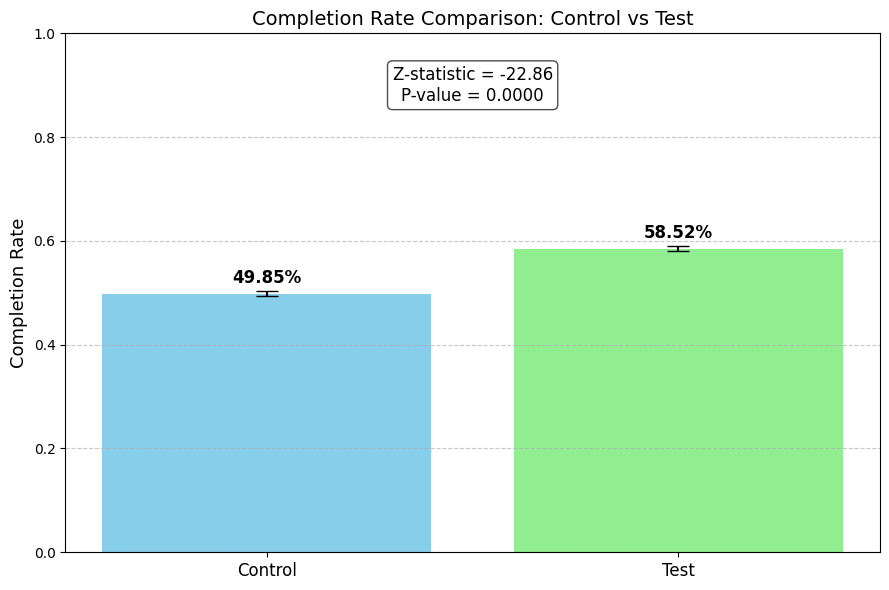

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Completion counts (replace with your actual values)
x_control = completions_per_group['Control']  # number of completions in control
x_test = completions_per_group['Test']        # number of completions in test
n_control = visits_per_group['Control']       # total visits in control
n_test = visits_per_group['Test']             # total visits in test

# Completion rates
control_rate = x_control / n_control
test_rate = x_test / n_test

# 95% confidence intervals for each group
conf_control = proportion_confint(x_control, n_control, alpha=0.05, method='wilson')
conf_test = proportion_confint(x_test, n_test, alpha=0.05, method='wilson')

# Z-test for proportions
z_stat, p_val = proportions_ztest([x_control, x_test], [n_control, n_test])

# Data for plotting
rates = [control_rate, test_rate]
conf_low = [control_rate - conf_control[0], test_rate - conf_test[0]]
conf_high = [conf_control[1] - control_rate, conf_test[1] - test_rate]

labels = ["Control", "Test"]
x = np.arange(len(labels))

# Plot bar chart
plt.figure(figsize=(9, 6))
bars = plt.bar(x, rates, yerr=[conf_low, conf_high], capsize=8, color=['skyblue', 'lightgreen'])

# Labels and title
plt.xticks(x, labels, fontsize=12)
plt.ylabel("Completion Rate", fontsize=13)
plt.title("Completion Rate Comparison: Control vs Test", fontsize=14)
plt.ylim(0, 1)

# Annotate bars with percentages
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{rates[i]*100:.2f}%", ha='center', fontsize=12, fontweight='bold')

# Add z-statistic and p-value on the chart
plt.text(0.5, 0.9,
         f"Z-statistic = {z_stat:.2f}\nP-value = {p_val:.4f}",
         ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
         transform=plt.gca().transAxes)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
#Error rate calculation
#H0: ER_new >= ER_old
#H1: ER_new < ER_old

#alternative=less
# st.ttest_ind(ER_new_sample, ER_old_sample, alternative = "less")
# -pvalue and 


In [31]:
import pandas as pd
import scipy.stats as st

# First, assign step order to detect backward navigation
step_order = {'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4, 'confirm': 5}
df_merged_exp['step_order'] = df_merged_exp['process_step'].map(step_order)

# Detect step-backs per visit
def count_stepbacks(steps):
    return sum(steps.iloc[i] < steps.iloc[i-1] for i in range(1, len(steps)))

errors_per_visit = df_merged_exp.groupby(['visit_id', 'Variation'])['step_order'] \
    .apply(count_stepbacks).reset_index(name='num_errors')

# Create a binary column: 1 = error occurred, 0 = no error
errors_per_visit['error_flag'] = (errors_per_visit['num_errors'] > 0).astype(int)

# Separate error samples by variation
ER_control = errors_per_visit.loc[errors_per_visit['Variation'] == 'Control', 'error_flag']
ER_test = errors_per_visit.loc[errors_per_visit['Variation'] == 'Test', 'error_flag']

In [32]:
t_stat, p_val = st.ttest_ind(ER_test, ER_control, alternative='less')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Control Error Rate: {ER_control.mean():.4f}")
print(f"Test Error Rate:    {ER_test.mean():.4f}")

T-statistic: 20.0856
P-value: 1.0000
Control Error Rate: 0.2044
Test Error Rate:    0.2695


In [33]:
# Interpret significance
alpha = 0.05
if p_val > alpha:
    print("We are not able to reject the null hypothesis.")
else:
    print("We reject the null hypotesis.")

We are not able to reject the null hypothesis.


Conclusion

We fail to reject the null hypothesis (H₀).

There’s no statistical evidence that the new design reduces error rates.

In fact, the new design increases the error rate.

In [34]:
#The average duration users spend on each step.
#H0: time_new >= time_old
#H1: time_new < time_old

#alternative=less
# st.ttest_ind(time_new_sample, time_old_sample, alternative = "less")
# -pvalue and compare pvalue with alpha

In [35]:
import scipy.stats as st

# Separate samples by Variation
time_new_sample = df_merged_exp[df_merged_exp['Variation'] == 'Test']['time_diff_sec'].dropna()
time_old_sample = df_merged_exp[df_merged_exp['Variation'] == 'Control']['time_diff_sec'].dropna()


# Perform one-tailed t-test (alternative = "less")
t_stat, p_val = st.ttest_ind(time_new_sample, time_old_sample, alternative='less')

print(f"time_new_sample: {time_new_sample.mean()}")
print(f"time_old_sample: {time_old_sample.mean()}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")


# Set significance level
alpha = 0.05
if p_val < alpha:
    print("Reject H₀: The new design takes more time than the old one.")
else:
    print("Fail to reject H₀: There is no evidence that the new design takes more time than the old design")

time_new_sample: 83.905510357655
time_old_sample: 81.96757202975405
T-statistic: 2.2501
P-value: 0.9878
Fail to reject H₀: There is no evidence that the new design takes more time than the old design


In [36]:
df_merged_exp.head(   )

,client_id,visitor_id,visit_id,process_step,date_time,time_diff,time_diff_sec,time_diff_min,Variation,step_num,step_order
0,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,NaT,NaN,NaN,Test,4,5
1,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,0 days 00:00:52,52.0,0.866667,Test,4,5
2,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,NaT,NaN,NaN,NaN,0,1
3,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,0 days 00:00:03,3.0,0.050000,NaN,1,2
4,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,0 days 00:00:24,24.0,0.400000,NaN,2,3


### For each visit_id, calculating the total time spent from the first recorded step to the last recorded step, then compare Test vs Control.

#The average duration users spend on each step.
#H0: time_new >= time_old
#H1: time_new < time_old

#alternative=less
# st.ttest_ind(time_new_sample, time_old_sample, alternative = "less")
# -pvalue and compare pvalue with alpha

Calculating below Total Time per Visit

In [37]:
import pandas as pd

# Ensure date_time is in datetime format
df_merged_exp['date_time'] = pd.to_datetime(df_merged_exp['date_time'], errors='coerce')

# Drop rows with missing timestamps
df_clean = df_merged_exp.dropna(subset=['date_time', 'visit_id', 'Variation'])

# Calculate start and end times per visit_id
df_total_time = (
    df_clean
    .groupby(['visit_id', 'Variation'], as_index=False)
    .agg(
        start_time=('date_time', 'min'),
        end_time=('date_time', 'max')
    )
)

# Calculate total journey time in seconds
df_total_time['total_time_sec'] = (df_total_time['end_time'] - df_total_time['start_time']).dt.total_seconds()

# Drop negative or zero durations, if any
df_total_time = df_total_time[df_total_time['total_time_sec'] > 0]

df_total_time.head()

,visit_id,Variation,start_time,end_time,total_time_sec
0,100012776_37918976071_457913,Test,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0
1,100019538_17884295066_43909,Test,2017-04-09 16:20:56,2017-04-09 16:24:58,242.0
2,100022086_87870757897_149620,Test,2017-05-23 20:44:01,2017-05-23 20:47:01,180.0
4,100037962_47432393712_705583,Control,2017-04-14 16:41:51,2017-04-14 16:44:03,132.0
5,100057941_88477660212_944512,Control,2017-04-09 11:30:10,2017-04-09 11:34:24,254.0


Comparing Test vs Control

In [38]:
import scipy.stats as st

# Separate total times by Variation
time_new_total = df_total_time[df_total_time['Variation'] == 'Test']['total_time_sec']
time_old_total = df_total_time[df_total_time['Variation'] == 'Control']['total_time_sec']

# One-tailed t-test (check if new design is faster → less time)
t_stat, p_val = st.ttest_ind(time_new_total, time_old_total, alternative='less')

print("=== Average Total Journey Times ===")
print(f"New design (Test)    mean: {time_new_total.mean():.2f} sec")
print(f"Old design (Control) mean: {time_old_total.mean():.2f} sec\n")

print("=== T-test Results ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value    : {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Reject H₀: The new design significantly reduces total completion time.")
else:
    print("Fail to reject H₀: There's no evidence that the new design is faster.")

=== Average Total Journey Times ===
New design (Test)    mean: 374.49 sec
Old design (Control) mean: 341.78 sec

=== T-test Results ===
T-statistic: 6.5466
P-value    : 1.0000
Fail to reject H₀: There's no evidence that the new design is faster.


# You might want to test if there are gender differences that affect engaging with the new or old process

Using Chi-Square Test of Independence

In [39]:
df_final_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [40]:
# Contingency table: Gender vs Variation (Test/Control)
contingency_table = pd.crosstab(df_final_demo['gendr'], df_experiment['Variation'])
print(contingency_table)

Variation  Control  Test
gendr                   
F             7591  8667
M             7865  9082
U             8070  9212


Null Hypothesis (H₀):
Gender and Variation are independent → gender does not affect engagement.

Alternative Hypothesis (H₁):
Gender and Variation are dependent → gender affects engagement.

In [41]:
from scipy.stats import chi2_contingency

# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print("\nExpected Frequencies:\n", expected)

# Significance level
alpha = 0.05
if p_value < alpha:
    print("✅ Reject H₀: Gender significantly affects engagement with the new vs old process.")
else:
    print("❌ Fail to reject H₀: No significant gender difference in engagement.")

Chi-Square Statistic: 0.3653
Degrees of Freedom: 2
P-value: 0.833071

Expected Frequencies:
 [[7575.92465387 8682.07534613]
 [7896.98579832 9050.01420168]
 [8053.0895478  9228.9104522 ]]
❌ Fail to reject H₀: No significant gender difference in engagement.


Visualization

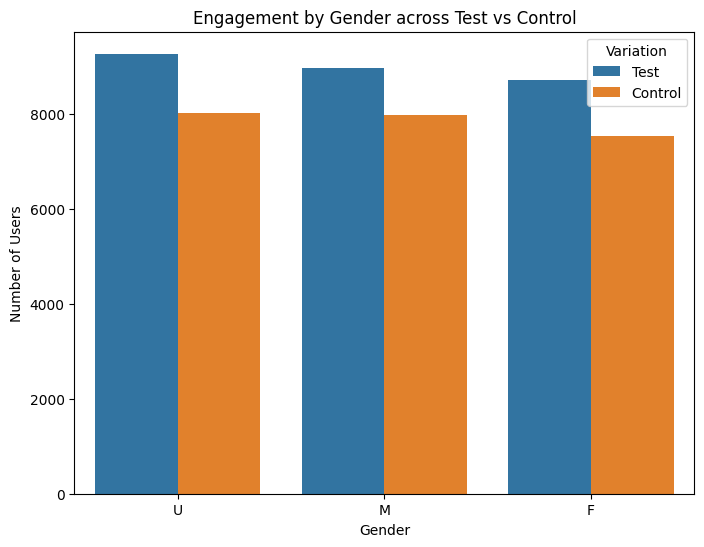

In [42]:
# Merge the dataframes to get both gender and variation in one df
df_demo_exp = df_final_demo.merge(df_experiment[['client_id', 'Variation']], on='client_id', how='inner')

# Plot engagement by gender across test vs control
plt.figure(figsize=(8,6))
sns.countplot(data=df_demo_exp, x='gendr', hue='Variation')
plt.title("Engagement by Gender across Test vs Control")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.legend(title="Variation")
plt.show()